##### HUGO GARCÍA SOUTO

# Image classification

In this notebook you will learn how to use two well known image classification techniques, the bag of words algorithm as well as the convolutional neural networks.

Requirements:
- Python 3
- opencv-python
- scikit-learn 


## The problem

Fashion-MNIST is a dataset of Zalando's article images, consisting of a training set of 60000 examples and a test set of 10000 examples. Both datasets are saved in a csv file where each line contains a label and the intensity values of a 28x28 grayscale image that depicts a piece of clothing. This dataset contains only objects of 10 classes.

The following function reads the contents of one of this csv files:

In [4]:
import numpy as np
import csv
import cv2 as cv
import matplotlib.pyplot as plt

In [5]:
# Load a csv file of the fashion MNIST dataset
# - filename: path filename of the csv file
# Returns the list of images and the list of corresponding labels

def load_mnist_dataset(filename):
    f = open(filename, 'r')
    reader = csv.reader(f, delimiter=',')
    data = []
    images = []
    labels = []
    next(reader)
    for row in reader:
        labels.append(int(row[0]))
        images.append(np.array(row[1:]).astype(np.uint8).reshape(28,28))
    f.close()
    return images, labels


We can use the previous function to read and display some images of both datasets (it can take a while):

In [6]:
train_images, train_labels = load_mnist_dataset("res/fashion-mnist_train.csv")
test_images, test_labels =  load_mnist_dataset("res/fashion-mnist_test.csv")

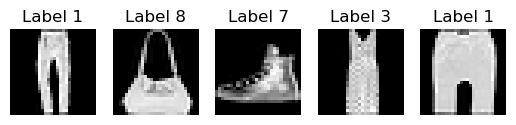

In [7]:
n_samples = 5

f, ax = plt.subplots(1,n_samples)
for i in range(n_samples):
    idx = np.random.randint(0, high=len(train_images))
    ax[i].imshow(train_images[idx], cmap='gray')
    ax[i].axis('off')
    ax[i].set_title(f'Label {train_labels[idx]}')
plt.show()

In this notebook you will develop a methodology to classify an input image into its corresponding label.

## Bag of words
The first approach will use the Bag of Words algorithm. This algorithm consists of the following steps:

1. Given a set of descriptors computed from the training images, define a vocabulary of visual words.
2. For each image in the training dataset
    1. Compute its descriptors
    2. Assign each descriptor to the closest word in the vocabulary
    3. Build a histogram of words
3. Use the histograms and the labels of each image in the training dataset to train a classifier 
4. Save both the vocabulary and trained classifier

For inference, follow the next steps:
1. Compute the descriptors of the input image
2. Assign each descriptor to the closest word in the saved vocabulary
3. Build the histogram
4. Use the trained classifier to obtain the label of the input image

### Step 1: Define a vocabulary of visual words


In order to build the vocabulary, the first step is to describe the input image using keypoints and its descriptors. To this end, you should use an efficient and robust algorithm, for example, SIFT. 



In [8]:
detector = cv.SIFT_create()

The second step is computing descriptors of images in training dataset and cluster all the gathered descriptors using a clustering algorithm, e.g. KMeans. The number of cluser centers defines the size of the vocabulary. The class `cv.BOWKMeansTrainer` helps with these tasks:

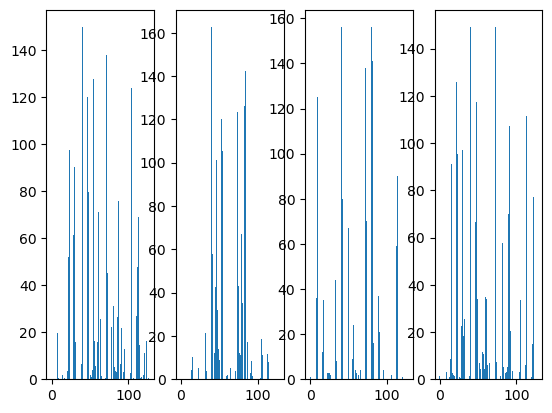

In [9]:
voc_size = 4 # Size of the vocabulary (toy example)

bow_trainer = cv.BOWKMeansTrainer(voc_size)

# Compute the descriptors of a image and add them to the bow trainer
image = train_images[0]
keypoints, descriptors = detector.detectAndCompute(image, np.ones(image.shape, dtype=np.uint8))
if descriptors is not None:
    bow_trainer.add(descriptors)

# Cluster the descriptors, this is, get the vocabulary
vocabulary = bow_trainer.cluster() 
f, ax = plt.subplots(1, voc_size)
for idx, word in enumerate(vocabulary):
    ax[idx].bar(range(0, word.shape[0]), word)
plt.show()

#### Exercise
Implement the following function that computes the vocabulary from the images in the training set.

**Note**: the number of descriptors in the training dataset (60000 images) is near 250k. In order to speed up the computation of the vocabulary, select only a random set of images of each class (10-20%).


In [10]:
def get_vocabulary(voc_size, images, labels, detector, output_filename):
    bow_trainer = cv.BOWKMeansTrainer(voc_size)
    
    # I use only a random subset of images from each class to speed up the process
    sample_fraction = 0.2   # 20% of the images of each class
    random_seed = 42
    rng = np.random.default_rng(random_seed)

    labels_array = np.array(labels)
    selected_indices = []

    # Select a balanced random subset from each class
    for class_label in np.unique(labels_array):
        class_indices = np.where(labels_array == class_label)[0]
        n_samples = int(len(class_indices) * sample_fraction)
        sampled_indices = rng.choice(class_indices, size=n_samples, replace=False)
        selected_indices.extend(sampled_indices)

    print(f"Using {len(selected_indices)} images to build the vocabulary.")

    total_descriptors = 0

    # Compute SIFT descriptors and add them to the BOW trainer
    for idx in selected_indices:
        image = images[idx]

        # Mask with ones: all pixels of the image are valid
        mask = np.ones(image.shape, dtype=np.uint8)

        keypoints, descriptors = detector.detectAndCompute(image, mask)

        # Some images may not produce descriptors
        if descriptors is not None:
            bow_trainer.add(descriptors)
            total_descriptors += descriptors.shape[0]

    print(f"Total descriptors added: {total_descriptors}")

    # Cluster the descriptors to obtain the visual vocabulary
    vocabulary = bow_trainer.cluster()

    # Save the vocabulary
    np.save(output_filename, vocabulary)

    return vocabulary

The function above builds a visual vocabulary using SIFT descriptors extracted from a balanced random subset of the training images. 

Since the complete training set contains 60,000 images, only 20% of the images from each class are used in order to reduce the computational cost while preserving the class distribution. For each selected image, SIFT keypoints and descriptors are computed. If an image does not produce descriptors, it is ignored.

All the extracted descriptors are added to the `BOWKMeansTrainer`, which applies K-Means clustering. The resulting cluster centers define the visual vocabulary. Finally, the vocabulary is saved using `np.save`.

#### Exercise
Compute and save vocabularies of three suitable sizes


In [11]:
# Define three suitable vocabulary sizes
voc_size_1 = 32
voc_size_2 = 64
voc_size_3 = 128

In [12]:
# Compute and save vocabulary size 1
vocabulary_1 = get_vocabulary(
    voc_size=voc_size_1,
    images=train_images,
    labels=train_labels,
    detector=detector,
    output_filename="vocabulary_32.npy"
)



Using 12000 images to build the vocabulary.
Total descriptors added: 48318


In [13]:
# Compute and save vocabulary size 2
vocabulary_2 = get_vocabulary(
    voc_size=voc_size_2,
    images=train_images,
    labels=train_labels,
    detector=detector,
    output_filename="vocabulary_64.npy"
)

Using 12000 images to build the vocabulary.
Total descriptors added: 48318


In [14]:
# Compute and save vocabulary size 3
vocabulary_3 = get_vocabulary(
    voc_size=voc_size_3,
    images=train_images,
    labels=train_labels,
    detector=detector,
    output_filename="vocabulary_128.npy"
)

Using 12000 images to build the vocabulary.
Total descriptors added: 48318


Three different vocabulary sizes were selected: 32, 64 and 128 visual words.

A smaller vocabulary is faster to compute but may not represent enough visual patterns. A larger vocabulary can capture more detailed visual structures, although it increases the computational cost. Comparing these three sizes allows us to evaluate how the vocabulary size affects the final classification performance.

### Step 2: Build histograms from the training dataset

The class `cv.BOWImgDescriptorExtractor` simplifies this operation. The constructor of this class needs two parameters: a keypoint detector and descriptor as well as an algorithm to match the descriptors to the cluster centers of the vocabulary. In our case, we use a brute force matcher and the SIFT detector that we have defined previously.

In [15]:
matcher = cv.BFMatcher(cv.NORM_L2)
bow_extractor = cv.BOWImgDescriptorExtractor(detector, matcher)

We have to init this class with a previously defined vocabulary.

In [16]:
bow_extractor.setVocabulary(vocabulary) # toy example

After that, we can compute the histogram of a given image as follows:

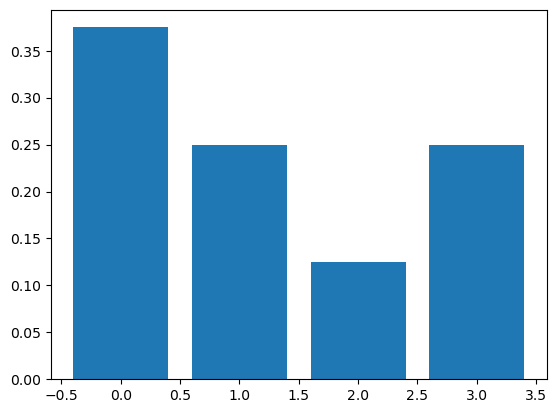

In [17]:
keypoints = detector.detect(train_images[0])
histograms = bow_extractor.compute(train_images[0], keypoints)
plt.bar(range(histograms[0].shape[0]), histograms[0])
plt.show()

Be careful, the output histogram is `None` when all its values are 0.

#### Exercise
Implement a function that computes the histograms of a set of images. If the `bow_extractor` returns `None` when computing the histogram, replace this value by an array of 0s.  

In [ ]:
def get_histograms(bow_extractor, images, vocabulary_size):
    histograms = []

    for image in images:
        # Detect keypoints in the image
        keypoints = detector.detect(image)

        # Compute the Bag of Words histogram
        histogram = bow_extractor.compute(image, keypoints)

        # If no histogram is obtained, replace it with a zero vector
        if histogram is None:
            histogram = np.zeros(vocabulary_size, dtype=np.float32)
        else:
            # bow_extractor.compute returns a shape like (1, vocabulary_size)
            # convert it to shape (vocabulary_size,)
            histogram = histogram.flatten()

        histograms.append(histogram)

    histograms = np.array(histograms)

    return histograms

This function converts a set of images into Bag of Visual Words histograms. For each image, SIFT keypoints are detected and the `BOWImgDescriptorExtractor` assigns the corresponding descriptors to the closest visual words of the vocabulary.

The resulting histogram represents how frequently each visual word appears in the image. If no valid histogram is obtained, a zero vector with the same size as the vocabulary is used instead.

### Step 3: Train a classifier
Use the histograms and the labels to train a classifier [(SVM, Random Forest, KNN, ...)](https://scikit-learn.org/stable/supervised_learning.html). Compute the success rate after training in the training set by comparing the classifier outputs with the actual labels as well as the [confusion matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html).

Repeat the procedure with the other two vocabularies that you have built.

**Important**: do not forget to set the appropriate vocabulary to the `bow_extractor`before computing the histograms

**Note**: if you use SVM, apply a grid search in order to find the best parameters.




In [21]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.base import clone
import pandas as pd
import joblib

In [22]:
def train_and_evaluate_models_for_vocabulary(
    vocabulary,
    vocabulary_size,
    vocabulary_name,
    bow_extractor,
    train_images,
    train_labels,
    max_samples_for_grid=10000,
    save_models=True
):
    """
    Computes Bag of Words histograms for a given vocabulary, trains several classifiers,
    evaluates them on the training set and shows the confusion matrix.

    Parameters
    ----------
    vocabulary : np.ndarray
        Visual vocabulary obtained with KMeans.
        
    vocabulary_size : int
        Number of visual words in the vocabulary.
        
    vocabulary_name : str
        Name used to identify the vocabulary in the results and saved models.
        
    bow_extractor : cv.BOWImgDescriptorExtractor
        Bag of Words descriptor extractor.
        
    train_images : list
        Training images.
        
    train_labels : list
        Training labels.
        
    max_samples_for_grid : int
        Maximum number of samples used during Grid Search. This is useful to reduce
        computation time. After finding the best parameters, the model is trained
        again using the full training set.
        
    save_models : bool
        If True, saves the trained models using joblib.

    Returns
    -------
    results_df : pd.DataFrame
        Summary table with the accuracy and best parameters of each model.
        
    trained_models : dict
        Dictionary containing the trained models.
        
    train_histograms : np.ndarray
        Bag of Words histograms computed from the training images.
    """

    print("=" * 80)
    print(f"Vocabulary: {vocabulary_name}")
    print(f"Vocabulary size: {vocabulary_size}")
    print("=" * 80)

    # Set the current vocabulary in the BOW extractor
    bow_extractor.setVocabulary(vocabulary)

    # Compute histograms for the full training set
    print("Computing training histograms...")
    train_histograms = get_histograms(
        bow_extractor=bow_extractor,
        images=train_images,
        vocabulary_size=vocabulary_size
    )

    X_train = train_histograms
    y_train = np.array(train_labels)

    print(f"Histograms shape: {X_train.shape}")

    # Use a subset for Grid Search if the dataset is large
    if max_samples_for_grid is not None and len(X_train) > max_samples_for_grid:
        X_grid, _, y_grid, _ = train_test_split(
            X_train,
            y_train,
            train_size=max_samples_for_grid,
            stratify=y_train,
            random_state=42
        )
    else:
        X_grid = X_train
        y_grid = y_train

    print(f"Samples used for Grid Search: {len(X_grid)}")

    # Define models and parameter grids
    models = {
        "Linear SVM": {
            "estimator": Pipeline([
                ("scaler", StandardScaler()),
                ("classifier", LinearSVC(random_state=42, max_iter=10000))
            ]),
            "params": {
                "classifier__C": [0.01, 0.1, 1, 10]
            }
        },

        "Random Forest": {
            "estimator": RandomForestClassifier(random_state=42, n_jobs=-1),
            "params": {
                "n_estimators": [100, 200],
                "max_depth": [None, 20],
                "min_samples_leaf": [1, 2]
            }
        },

        "KNN": {
            "estimator": Pipeline([
                ("scaler", StandardScaler()),
                ("classifier", KNeighborsClassifier())
            ]),
            "params": {
                "classifier__n_neighbors": [3, 5, 7],
                "classifier__weights": ["uniform", "distance"]
            }
        }
    }

    results = []
    trained_models = {}

    # Train and evaluate each model
    for model_name, model_info in models.items():
        print("\n" + "-" * 80)
        print(f"Training model: {model_name}")
        print("-" * 80)

        estimator = model_info["estimator"]
        param_grid = model_info["params"]

        # Grid Search
        grid_search = GridSearchCV(
            estimator=estimator,
            param_grid=param_grid,
            cv=3,
            scoring="accuracy",
            n_jobs=-1
        )

        grid_search.fit(X_grid, y_grid)

        print(f"Best parameters: {grid_search.best_params_}")
        print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

        # Train the best model again using the full training set
        best_model = clone(grid_search.best_estimator_)
        best_model.fit(X_train, y_train)

        # Predict on the training set
        train_predictions = best_model.predict(X_train)

        # Compute success rate
        train_accuracy = accuracy_score(y_train, train_predictions)

        # Compute confusion matrix
        cm = confusion_matrix(y_train, train_predictions)

        print(f"Training accuracy: {train_accuracy:.4f}")

        # Display confusion matrix
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(cmap="Blues", values_format="d")
        plt.title(f"{model_name} - {vocabulary_name} - Training confusion matrix")
        plt.show()

        # Save result
        results.append({
            "Vocabulary": vocabulary_name,
            "Vocabulary size": vocabulary_size,
            "Model": model_name,
            "Best CV accuracy": grid_search.best_score_,
            "Training accuracy": train_accuracy,
            "Best parameters": grid_search.best_params_
        })

        trained_models[model_name] = best_model

        if save_models:
            model_filename = f"{vocabulary_name}_{model_name.replace(' ', '_')}.joblib"
            joblib.dump(best_model, model_filename)
            print(f"Model saved as: {model_filename}")

    results_df = pd.DataFrame(results)

    return results_df, trained_models, train_histograms

Vocabulary: vocabulary_32
Vocabulary size: 32
Computing training histograms...
Histograms shape: (60000, 32)
Samples used for Grid Search: 10000

--------------------------------------------------------------------------------
Training model: Linear SVM
--------------------------------------------------------------------------------


c:\Users\Hugo\miniconda3\envs\cv1\lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
c:\Users\Hugo\miniconda3\envs\cv1\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Hugo\miniconda3\envs\cv1\lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


Best parameters: {'classifier__C': 1}
Best cross-validation accuracy: 0.4585


c:\Users\Hugo\miniconda3\envs\cv1\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Training accuracy: 0.4710


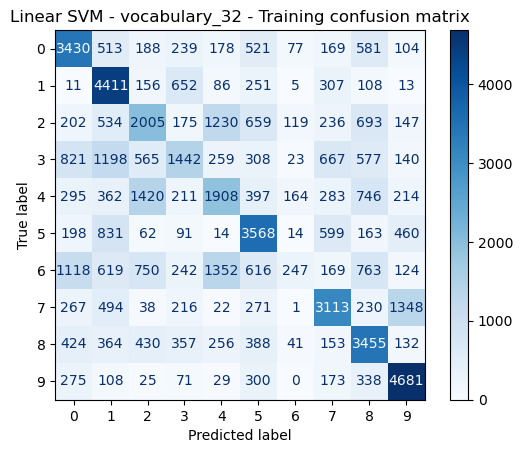

Model saved as: vocabulary_32_Linear_SVM.joblib

--------------------------------------------------------------------------------
Training model: Random Forest
--------------------------------------------------------------------------------
Best parameters: {'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 200}
Best cross-validation accuracy: 0.4712
Training accuracy: 0.6559


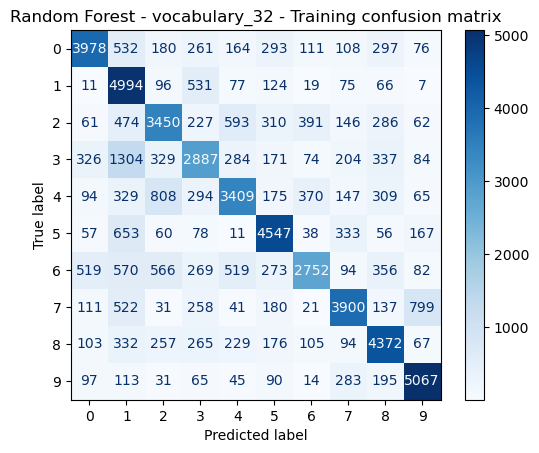

Model saved as: vocabulary_32_Random_Forest.joblib

--------------------------------------------------------------------------------
Training model: KNN
--------------------------------------------------------------------------------
Best parameters: {'classifier__n_neighbors': 7, 'classifier__weights': 'uniform'}
Best cross-validation accuracy: 0.4355
Training accuracy: 0.5327


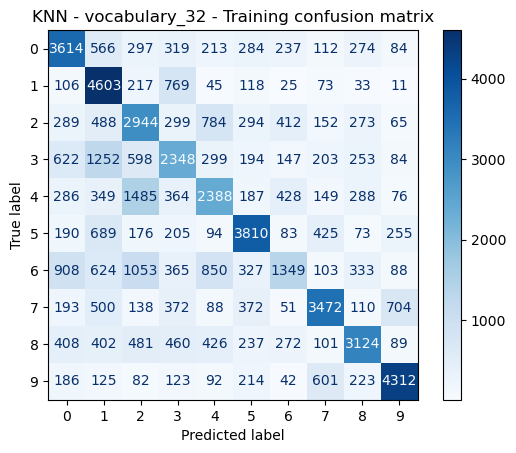

Model saved as: vocabulary_32_KNN.joblib


In [23]:
# Train and evaluate models using vocabulary size 1
results_voc_1, models_voc_1, train_histograms_voc_1 = train_and_evaluate_models_for_vocabulary(
    vocabulary=vocabulary_1,
    vocabulary_size=voc_size_1,
    vocabulary_name="vocabulary_32",
    bow_extractor=bow_extractor,
    train_images=train_images,
    train_labels=train_labels
)


Vocabulary: vocabulary_64
Vocabulary size: 64
Computing training histograms...
Histograms shape: (60000, 64)
Samples used for Grid Search: 10000

--------------------------------------------------------------------------------
Training model: Linear SVM
--------------------------------------------------------------------------------


c:\Users\Hugo\miniconda3\envs\cv1\lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


Best parameters: {'classifier__C': 0.1}
Best cross-validation accuracy: 0.5160


c:\Users\Hugo\miniconda3\envs\cv1\lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


Training accuracy: 0.5356


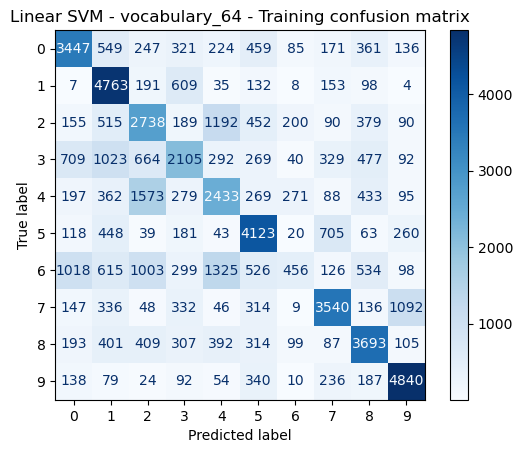

Model saved as: vocabulary_64_Linear_SVM.joblib

--------------------------------------------------------------------------------
Training model: Random Forest
--------------------------------------------------------------------------------
Best parameters: {'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 200}
Best cross-validation accuracy: 0.5217
Training accuracy: 0.7064


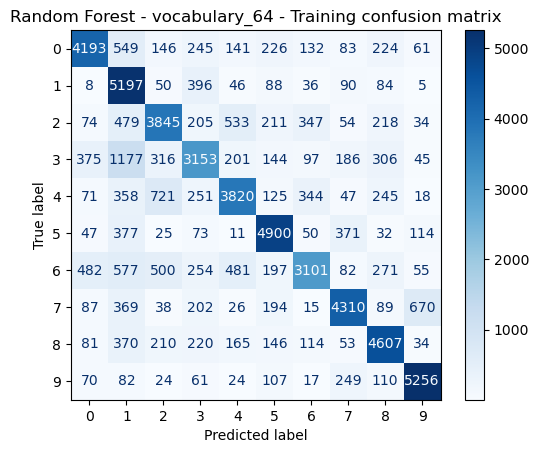

Model saved as: vocabulary_64_Random_Forest.joblib

--------------------------------------------------------------------------------
Training model: KNN
--------------------------------------------------------------------------------
Best parameters: {'classifier__n_neighbors': 7, 'classifier__weights': 'uniform'}
Best cross-validation accuracy: 0.4629
Training accuracy: 0.5883


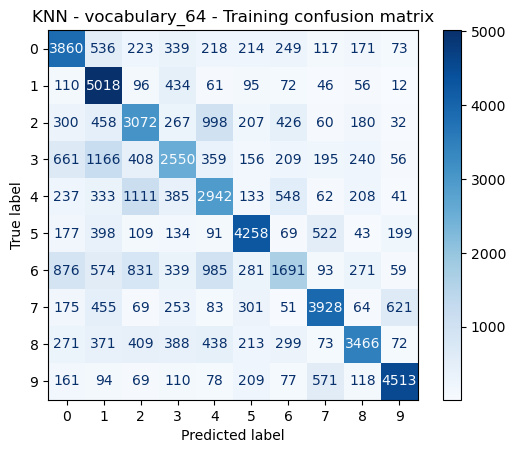

Model saved as: vocabulary_64_KNN.joblib


In [24]:
# Train and evaluate models using vocabulary size 2
results_voc_2, models_voc_2, train_histograms_voc_2 = train_and_evaluate_models_for_vocabulary(
    vocabulary=vocabulary_2,
    vocabulary_size=voc_size_2,
    vocabulary_name="vocabulary_64",
    bow_extractor=bow_extractor,
    train_images=train_images,
    train_labels=train_labels
)

Vocabulary: vocabulary_128
Vocabulary size: 128
Computing training histograms...
Histograms shape: (60000, 128)
Samples used for Grid Search: 10000

--------------------------------------------------------------------------------
Training model: Linear SVM
--------------------------------------------------------------------------------


c:\Users\Hugo\miniconda3\envs\cv1\lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


Best parameters: {'classifier__C': 0.1}
Best cross-validation accuracy: 0.5612


c:\Users\Hugo\miniconda3\envs\cv1\lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


Training accuracy: 0.5829


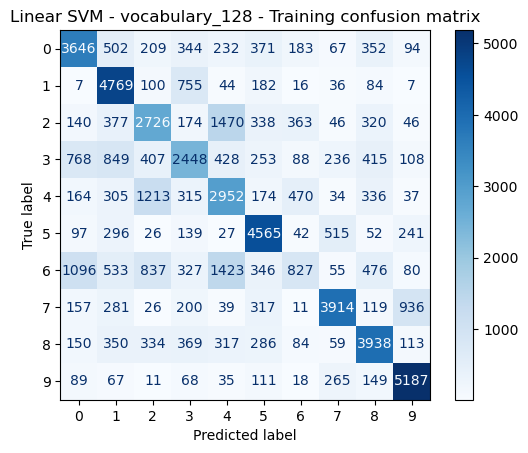

Model saved as: vocabulary_128_Linear_SVM.joblib

--------------------------------------------------------------------------------
Training model: Random Forest
--------------------------------------------------------------------------------
Best parameters: {'max_depth': None, 'min_samples_leaf': 2, 'n_estimators': 200}
Best cross-validation accuracy: 0.5553
Training accuracy: 0.7228


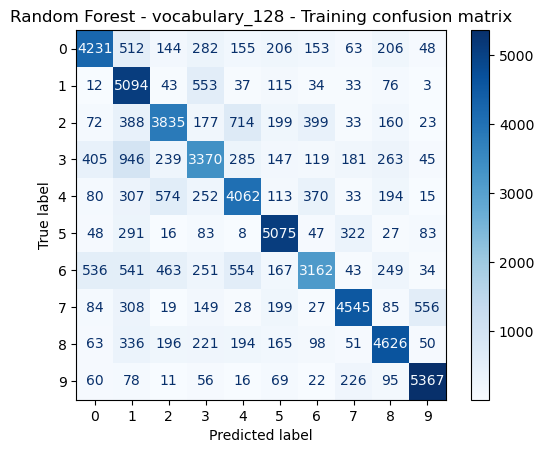

Model saved as: vocabulary_128_Random_Forest.joblib

--------------------------------------------------------------------------------
Training model: KNN
--------------------------------------------------------------------------------
Best parameters: {'classifier__n_neighbors': 7, 'classifier__weights': 'distance'}
Best cross-validation accuracy: 0.4770
Training accuracy: 0.8369


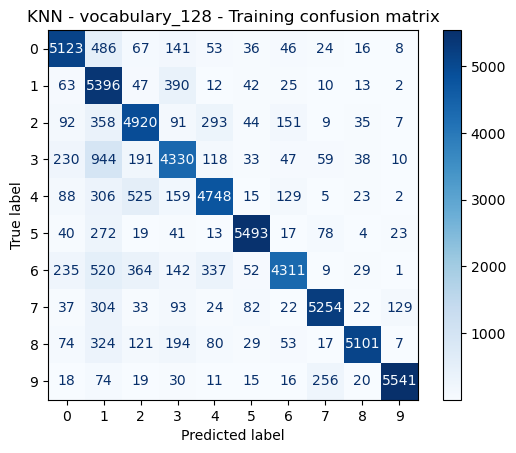

Model saved as: vocabulary_128_KNN.joblib


In [25]:
# Train and evaluate models using vocabulary size 3
results_voc_3, models_voc_3, train_histograms_voc_3 = train_and_evaluate_models_for_vocabulary(
    vocabulary=vocabulary_3,
    vocabulary_size=voc_size_3,
    vocabulary_name="vocabulary_128",
    bow_extractor=bow_extractor,
    train_images=train_images,
    train_labels=train_labels
)

Several classifiers were trained using the Bag of Visual Words histograms obtained from each vocabulary size. The evaluated models were Linear SVM, Random Forest and KNN.

For each classifier, a Grid Search with 3-fold cross-validation was applied in order to select suitable hyperparameters. To reduce computational cost, the Grid Search was performed on a stratified subset of the training data. Once the best parameters were found, the final model was trained again using the complete training set.

The training success rate was computed by comparing the predicted labels with the true labels from the training set. In addition, the confusion matrix was displayed for each model in order to analyse which classes are more frequently confused.

In [26]:
all_results = pd.concat(
    [results_voc_1, results_voc_2, results_voc_3],
    ignore_index=True
)

all_results.sort_values(by="Training accuracy", ascending=False)

,Vocabulary,Vocabulary size,Model,Best CV accuracy,Training accuracy,Best parameters
8,vocabulary_128,128,KNN,0.476999,0.836950,"{'classifier__n_neighbors': 7, 'classifier__we..."
7,vocabulary_128,128,Random Forest,0.555301,0.722783,"{'max_depth': None, 'min_samples_leaf': 2, 'n_..."
4,vocabulary_64,64,Random Forest,0.521701,0.706367,"{'max_depth': None, 'min_samples_leaf': 2, 'n_..."
1,vocabulary_32,32,Random Forest,0.471200,0.655933,"{'max_depth': None, 'min_samples_leaf': 2, 'n_..."
5,vocabulary_64,64,KNN,0.462900,0.588300,"{'classifier__n_neighbors': 7, 'classifier__we..."
6,vocabulary_128,128,Linear SVM,0.561200,0.582867,{'classifier__C': 0.1}
3,vocabulary_64,64,Linear SVM,0.516000,0.535633,{'classifier__C': 0.1}
2,vocabulary_32,32,KNN,0.435500,0.532733,"{'classifier__n_neighbors': 7, 'classifier__we..."
0,vocabulary_32,32,Linear SVM,0.458500,0.471000,{'classifier__C': 1}


The results show that increasing the vocabulary size generally improves the classification performance. The best cross-validation accuracy is obtained with the vocabulary of 128 visual words and the Linear SVM classifier.

Although KNN with the vocabulary of 128 visual words obtains the highest training accuracy, its cross-validation accuracy is considerably lower. This suggests that KNN is overfitting the training data and does not generalize as well as the other models.

For this reason, the model selected for the final evaluation on the test set is the Linear SVM trained with the vocabulary of 128 visual words, since it provides the best cross-validation accuracy and a more balanced behaviour between training and validation.

### Step 4: Test the classifier

Test the classifier with the test dataset, compute the success rate and the confussion matrix.

In [28]:
# Select the best model according to cross-validation accuracy
best_result_idx = all_results["Best CV accuracy"].idxmax()
best_result = all_results.loc[best_result_idx]

best_vocabulary_name = best_result["Vocabulary"]
best_vocabulary_size = best_result["Vocabulary size"]
best_model_name = best_result["Model"]

print("Best model selected:")
print(f"Vocabulary: {best_vocabulary_name}")
print(f"Vocabulary size: {best_vocabulary_size}")
print(f"Model: {best_model_name}")
print(f"Best CV accuracy: {best_result['Best CV accuracy']:.4f}")
print(f"Training accuracy: {best_result['Training accuracy']:.4f}")
print(f"Best parameters: {best_result['Best parameters']}")

Best model selected:
Vocabulary: vocabulary_128
Vocabulary size: 128
Model: Linear SVM
Best CV accuracy: 0.5612
Training accuracy: 0.5829
Best parameters: {'classifier__C': 0.1}


In [29]:
# Dictionary to retrieve the vocabulary and trained models
vocabulary_models = {
    "vocabulary_32": {
        "vocabulary": vocabulary_1,
        "vocabulary_size": voc_size_1,
        "models": models_voc_1
    },
    "vocabulary_64": {
        "vocabulary": vocabulary_2,
        "vocabulary_size": voc_size_2,
        "models": models_voc_2
    },
    "vocabulary_128": {
        "vocabulary": vocabulary_3,
        "vocabulary_size": voc_size_3,
        "models": models_voc_3
    }
}

# Retrieve the selected vocabulary and model
best_vocabulary = vocabulary_models[best_vocabulary_name]["vocabulary"]
best_vocabulary_size = vocabulary_models[best_vocabulary_name]["vocabulary_size"]
best_model = vocabulary_models[best_vocabulary_name]["models"][best_model_name]

In [30]:
# Step 4: Test the selected classifier

print("Testing the selected model...")
print(f"Selected vocabulary: {best_vocabulary_name}")
print(f"Selected model: {best_model_name}")

# Set the selected vocabulary in the BOW extractor
bow_extractor.setVocabulary(best_vocabulary)

# Compute Bag of Words histograms for the test images
test_histograms = get_histograms(
    bow_extractor=bow_extractor,
    images=test_images,
    vocabulary_size=best_vocabulary_size
)

X_test = test_histograms
y_test = np.array(test_labels)

print(f"Test histograms shape: {X_test.shape}")

# Predict labels for the test set
test_predictions = best_model.predict(X_test)

# Compute test accuracy
test_accuracy = accuracy_score(y_test, test_predictions)

print(f"Test accuracy: {test_accuracy:.4f}")


Testing the selected model...
Selected vocabulary: vocabulary_128
Selected model: Linear SVM
Test histograms shape: (10000, 128)
Test accuracy: 0.5784


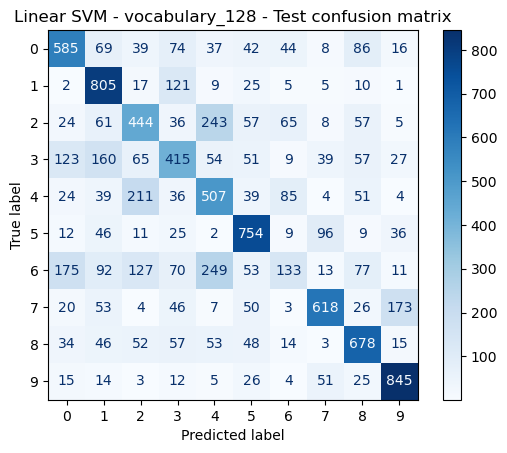

In [31]:
# Compute and display the confusion matrix
test_cm = confusion_matrix(y_test, test_predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=test_cm)
disp.plot(cmap="Blues", values_format="d")
plt.title(f"{best_model_name} - {best_vocabulary_name} - Test confusion matrix")
plt.show()

The selected model was evaluated on the test dataset, which contains images that were not used during training. First, the same visual vocabulary used during training was assigned to the Bag of Words extractor. Then, the test images were converted into Bag of Visual Words histograms.

The trained classifier was used to predict the labels of the test images. Finally, the success rate was computed by comparing the predicted labels with the true labels, and the confusion matrix was displayed to analyse the classification errors.

In [32]:
final_test_result = pd.DataFrame([{
    "Selected vocabulary": best_vocabulary_name,
    "Vocabulary size": best_vocabulary_size,
    "Selected model": best_model_name,
    "Test accuracy": test_accuracy
}])

final_test_result

,Selected vocabulary,Vocabulary size,Selected model,Test accuracy
0,vocabulary_128,128,Linear SVM,0.5784


The selected model was the Linear SVM trained with the vocabulary of 128 visual words. This model obtained a test accuracy of 0.5784.

This result is consistent with the cross-validation accuracy obtained during training, which indicates that the model does not present a strong overfitting problem. Although the accuracy is moderate, this is expected because Fashion-MNIST images are very small and the Bag of Visual Words approach only uses local SIFT descriptors, without explicitly preserving the spatial structure of the image.

Therefore, the Bag of Visual Words model is able to capture some discriminative visual patterns, but its performance is limited compared with more modern approaches such as convolutional neural networks.